# Modelling Credit Card Fraud

This notebook continues from the Exploratory Data Analysis (EDA) done in [`dataCollections.ipynb`](dataCollections.ipynb). In this part, we wish to use machine learning techniques to extract valuable insights from the data and apply various models to see which ones perform the best at predicting fraud.

## Setup
First, we reload the data and the corresponding libraries needed along with initializing a random seed.


In [25]:
%load_ext autoreload
%autoreload 2

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../python") 
import inspect

from model_functions import evaluate_model, make_models

from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve, f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

import xgboost as xgb
import lightgbm as lgb

seed = 31415
np.random.seed(seed)

path = kagglehub.dataset_download('whenamancodes/fraud-detection')
df = pd.read_csv(path + '/creditcard.csv')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Preproccessing

In the preprocessing stage, we wish to transform the amounts field to an appropriate range. This is done since features V1-V28 are obtained by PCA.

In [26]:
df_t = df.copy()

# Robust scaler since we have many outliers.
scaler = RobustScaler()

# Temporary since we will scale later
df_t['Amount_scaled'] = df_t['Amount']

df_t['Hour'] = (df_t['Time'] % 86400) / 3600

# Get rid of redundant
df_t = df_t.drop(columns=['Time','Amount'])

## Train/Test Split

Next we split the data into 80% training data and 20% test data. This ensures that we can adequately train our models while leaving a large enough test sample to evaluate the models.

In [27]:
print("df_t columns:", df_t.columns.tolist())
print("df columns:", df.columns.tolist())

df_t columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Hour']
df columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [28]:
X = df_t.drop('Class', axis=1)
y = df_t['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=seed
)

X_train[['Amount_scaled', 'Hour']] = scaler.fit_transform(X_train[['Amount_scaled', 'Hour']])
X_test[['Amount_scaled', 'Hour']] = scaler.transform(X_test[['Amount_scaled', 'Hour']])

In [29]:
print(f"Train: {X_train.shape}, fraud rate: {y_train.mean()*100:.3f}%")
print(f"Test:  {X_test.shape}, fraud rate: {y_test.mean()*100:.3f}%")
print("\nScaled columns:")
print(X_train[['Amount_scaled', 'Hour']].describe())

Train: (227845, 30), fraud rate: 0.173%
Test:  (56962, 30), fraud rate: 0.172%

Scaled columns:
       Amount_scaled           Hour
count  227845.000000  227845.000000
mean        0.926642      -0.053893
std         3.541310       0.670046
min        -0.307994      -1.721776
25%        -0.230015      -0.505352
50%         0.000000       0.000000
75%         0.769985       0.494648
max       359.361053       1.030454


## Handling Class Imbalance

Since the dataset has 0.17% fraudulent activity, the data is extremely imbalanced. To address this we use the Synthetic Minority Over-sampling Technique otherwise known as SMOTE. This technique generates synthetic samples for the fraud class, via interpolation of other points. Without handling the class imbalance, all models would predict legitimate transactions repeatedly since there are almost no fraud classes relevant to legitimate ones. We also run RandomUnderSampler to use undersampling by throwing away legit transactions until we have a balanced data set. The advantage to undersampling is that we do not create synthetic data, but we suffer from having to disregard 99% of the data. In order to select the best approach, we will compare all three options of undersampling, SMOTE, and keeping the original data.

In [30]:
sm = SMOTE(random_state=seed)
X_train_smote, y_train_smote = sm.fit_resample(X_train,y_train)

rus = RandomUnderSampler(random_state=seed)
X_train_drop, y_train_drop = rus.fit_resample(X_train, y_train)

datasets = {
    'Regular': (X_train, y_train),
    'SMOTE': (X_train_smote, y_train_smote),
    'Undersampling': (X_train_drop, y_train_drop),
}

## All datasets on all models

Here we wish to run all three datasets: default data, SMOTE balanced data, and undersampled data across all four models: logistic regression, random forest, XGBoost, LightGBM. This will give us a complete analysis on each model and will not miss any possible interactions with a weak model but strong data or the converse.

In [31]:
results = []
trained_models = {}

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
# Get the amount of non-fraud (negative), fraud (positive)
# Compute the ratio of how many more fraud to non fraud
scale_pos_weight = neg/pos
# This weighs the fraud class roughly 580 times more than non-fraud


for data_name, (X,Y) in  datasets.items():
    include_weights = (data_name == 'Regular')
    models = make_models(scale_pos_weight,include_weights)

    for model_name, model in models.items():
        fullname = f'{model_name} - {data_name}'
        print(f'Training: {fullname}')
        model.fit(X,Y)
        trained_models[fullname] = model
        metric = evaluate_model(model, X_test, y_test, model_name=f'{fullname}', threshold=0.5, show_plots=False)
        print()
        results.append(metric)

results_df = pd.DataFrame(results).sort_values('PR-AUC',ascending=False)


Training: Logistic Regression - Regular
Logistic Regression - Regular Evaluation:
Accuracy: 0.9772
Precision: 0.0652
Recall: 0.9184
F1 Score: 0.1217
ROC-AUC Score: 0.9762
PR-AUC Score: 0.6597

Training: Random Forest - Regular
Random Forest - Regular Evaluation:
Accuracy: 0.9994
Precision: 0.8081
Recall: 0.8163
F1 Score: 0.8122
ROC-AUC Score: 0.9832
PR-AUC Score: 0.7841

Training: XGBoost - Regular
XGBoost - Regular Evaluation:
Accuracy: 0.9996
Precision: 0.9294
Recall: 0.8061
F1 Score: 0.8634
ROC-AUC Score: 0.9844
PR-AUC Score: 0.8498

Training: LightGBM - Regular
LightGBM - Regular Evaluation:
Accuracy: 0.9718
Precision: 0.0507
Recall: 0.8673
F1 Score: 0.0957
ROC-AUC Score: 0.9163
PR-AUC Score: 0.0458

Training: Logistic Regression - SMOTE
Logistic Regression - SMOTE Evaluation:
Accuracy: 0.9765
Precision: 0.0635
Recall: 0.9184
F1 Score: 0.1187
ROC-AUC Score: 0.9732
PR-AUC Score: 0.6623

Training: Random Forest - SMOTE
Random Forest - SMOTE Evaluation:
Accuracy: 0.9983
Precision: 0.5

## Visualization

Below are the PR-AUC scores plotted on a heatmap for all 12 samples.

                     Model  Accuracy  Precision    Recall        F1   ROC-AUC  \
2        XGBoost - Regular  0.999561   0.929412  0.806122  0.863388  0.984394   
6          XGBoost - SMOTE  0.999280   0.782178  0.806122  0.793970  0.982764   
7         LightGBM - SMOTE  0.999333   0.806122  0.806122  0.806122  0.982630   
1  Random Forest - Regular  0.999350   0.808081  0.816327  0.812183  0.983239   
5    Random Forest - SMOTE  0.998280   0.500000  0.826531  0.623077  0.987645   

     PR-AUC  Threshold      ModelName Strategy  
2  0.849771        0.5        XGBoost  Regular  
6  0.826671        0.5        XGBoost    SMOTE  
7  0.812643        0.5       LightGBM    SMOTE  
1  0.784085        0.5  Random Forest  Regular  
5  0.769737        0.5  Random Forest    SMOTE  


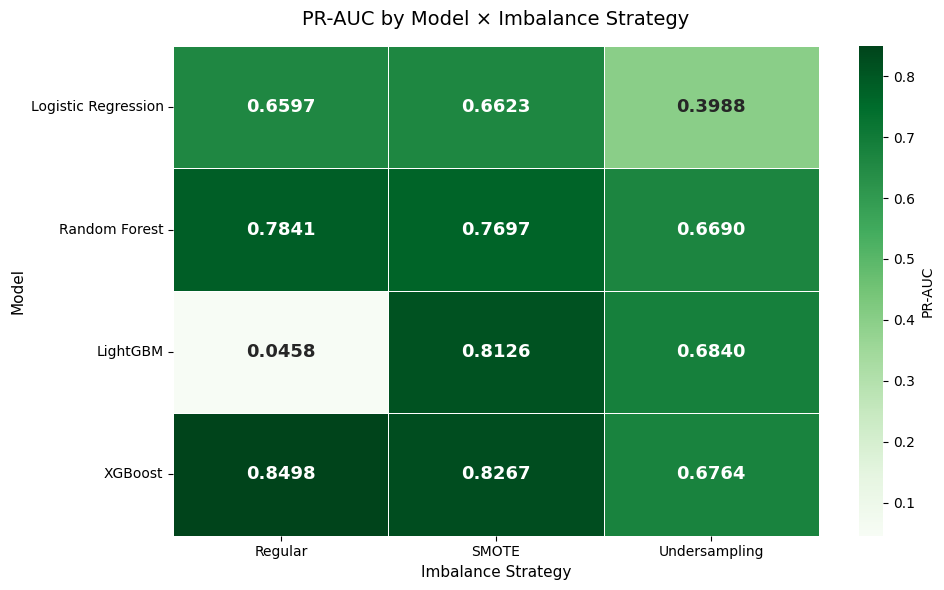

In [32]:
#print(results_df.columns.tolist())
# Assumes results_df has a 'Model' column like "XGBoost | SMOTE"
results_df[['ModelName', 'Strategy']] = results_df['Model'].str.split(r' - ', expand=True)
print(results_df.head())


pivot = results_df.pivot(index='ModelName', columns='Strategy', values='PR-AUC')

# Reorder for nicer reading (strongest models on top)
model_order = ['Logistic Regression', 'Random Forest', 'LightGBM', 'XGBoost']
strategy_order = ['Regular', 'SMOTE', 'Undersampling']
pivot = pivot.reindex(index=model_order, columns=strategy_order)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='Greens',
            cbar_kws={'label': 'PR-AUC'},
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})
plt.title('PR-AUC by Model × Imbalance Strategy', fontsize=14, pad=15)
plt.xlabel('Imbalance Strategy', fontsize=11)
plt.ylabel('Model', fontsize=11)
plt.tight_layout()
plt.savefig('results_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

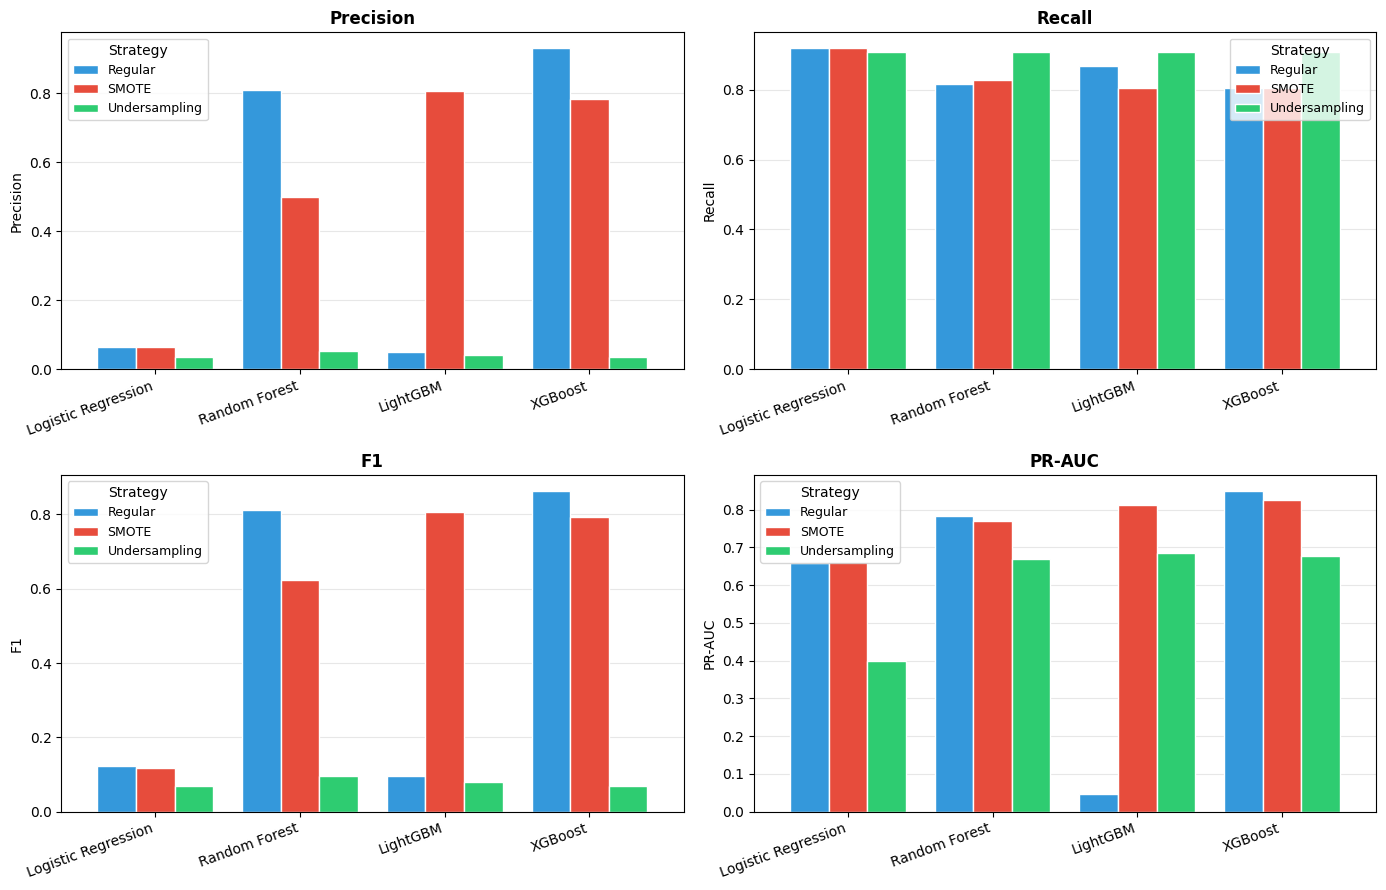

In [33]:
# Pick metrics to display
metrics_to_plot = ['Precision', 'Recall', 'F1', 'PR-AUC']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

colors = {'Regular': '#3498db', 'SMOTE': '#e74c3c', 'Undersampling': '#2ecc71'}

for ax, metric in zip(axes, metrics_to_plot):
    pivot = results_df.pivot(index='ModelName', columns='Strategy', values=metric)
    pivot = pivot.reindex(index=model_order, columns=strategy_order)
    pivot.plot(kind='bar', ax=ax, color=[colors[s] for s in pivot.columns],
               edgecolor='white', width=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    ax.legend(title='Strategy', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('results_grouped_bars.png', dpi=150, bbox_inches='tight')
plt.show()

Next we plot the evaluation metrics for the two winners Random Forest and XGBoost.

XGBoost with SMOTE Evaluation:
Accuracy: 0.9993
Precision: 0.7822
Recall: 0.8061
F1 Score: 0.7940
ROC-AUC Score: 0.9828
PR-AUC Score: 0.8267


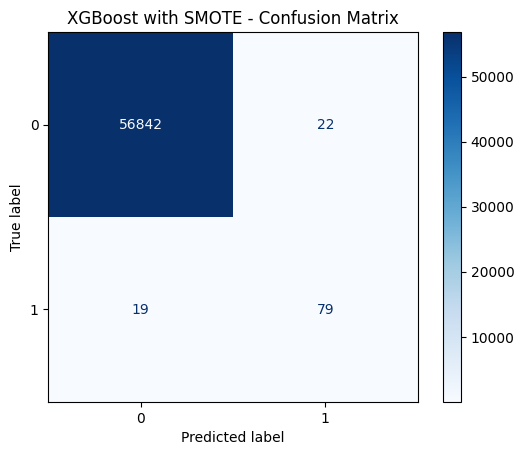

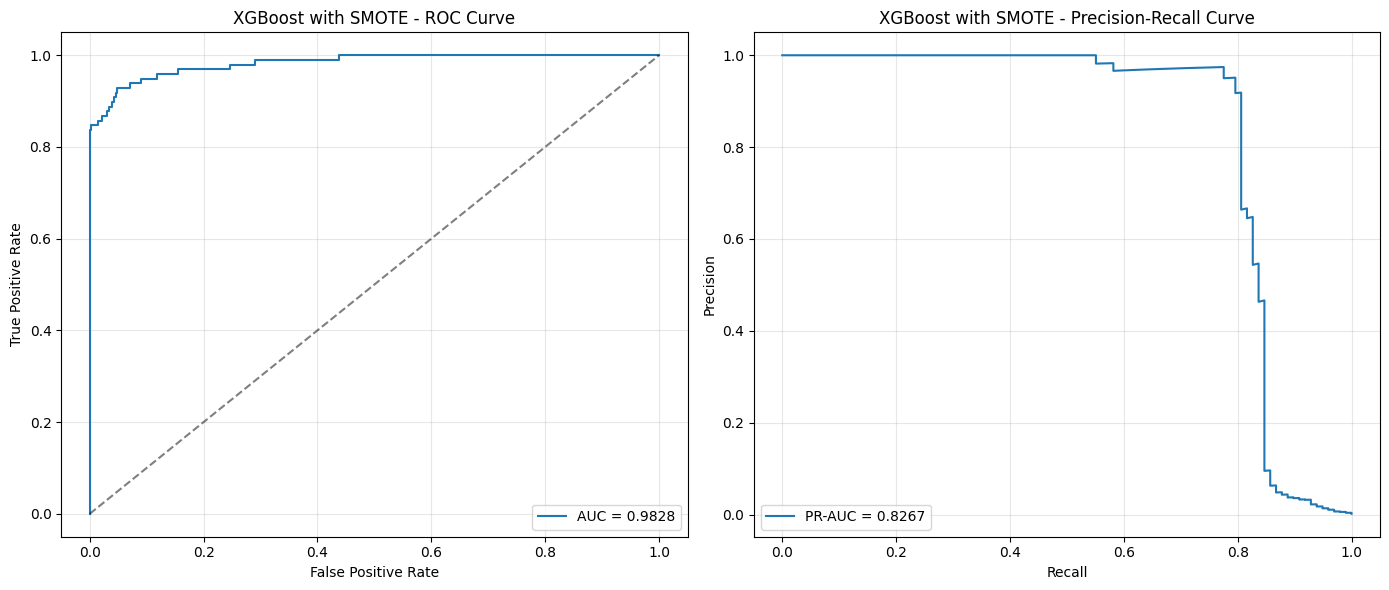

{'Model': 'XGBoost with SMOTE',
 'Accuracy': 0.9992802219023208,
 'Precision': 0.7821782178217822,
 'Recall': 0.8061224489795918,
 'F1': 0.7939698492462312,
 'ROC-AUC': 0.9827644620031468,
 'PR-AUC': 0.8266710679051176,
 'Threshold': 0.5}

In [34]:
evaluate_model(trained_models['XGBoost - SMOTE'], X_test, y_test, "XGBoost with SMOTE", show_plots=True)

## Logistic Regression

The logistic regression is often considered the gold standard when it comes to classification problems. It should come as no surprise that we choose to first use the logistic regression method on our data. Afterwards, we pass the logistic regression model to our evaluate function to collect the results of this model.

In [35]:
#logreg = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=seed)
#logreg.fit(X_train,y_train)
# Call evaluate metric = evaluate('Logistic Regression', logreg, X_test, y_test)

# Keep all metrics in results for later comparison.
#results.append(metric)


## Random Forest

Next we aim to use the random forest classifier which uses a collection of decision trees amalgamated into a single, comprehensive structure. This allows more accurate classification than a single decision tree, since we are taking an average over many such classifications.

In [36]:
#rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', n_jobs=-1, random_state=seed)
#rf.fit(X_train, y_train)
# Call evaluate metric = evaluate('Random Forest', rf, X_test, y_test)

#results.append(metric)


## XGBoost

Historically, gradient boosting dominates Kaggle competitions, for this reason along it is a strong contender on this dataset.
Additionally, the ability of each tree to learn from the errors of prior trees allows the model to pick up subtle patterns within fraud behaviour.

In [37]:
#neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
# Get the amount of non-fraud (negative), fraud (positive)
# Compute the ratio of how many more fraud to non fraud
#scale_pos_weight = neg/pos
# This weighs the fraud class roughly 580 times more than non-fraud

#xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
            #scale_pos_weight=scale_pos_weight, eval_metric='aucpr', n_jobs=-1, random_state=seed)

#evaluate('XGBoost', xgb_model, X_test, y_test)



(model, x_test, y_test, model_name='Model', threshold=0.5, show_plots=True)
Logistic Regression Evaluation:
Accuracy: 0.9772
Precision: 0.0652
Recall: 0.9184
F1 Score: 0.1217
ROC-AUC Score: 0.9762
PR-AUC Score: 0.6597


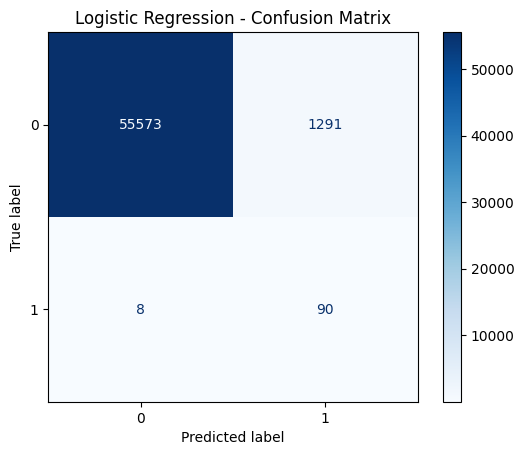

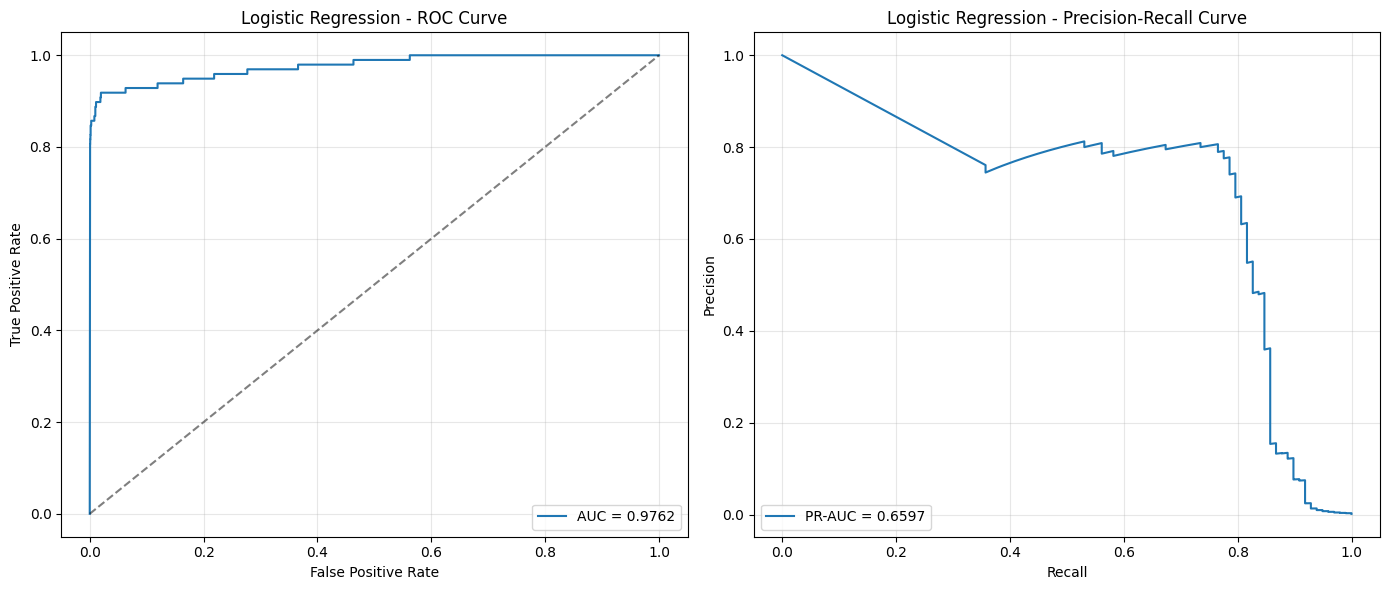

{'Model': 'Logistic Regression',
 'Accuracy': 0.9771953231979215,
 'Precision': 0.06517016654598118,
 'Recall': 0.9183673469387755,
 'F1': 0.12170385395537525,
 'ROC-AUC': 0.976195171723726,
 'PR-AUC': 0.6596850295471168,
 'Threshold': 0.5}

In [38]:
logreg = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=seed)
logreg.fit(X_train,y_train)
# Call evaluate metric = evaluate('Logistic Regression', logreg, X_test, y_test)

# Keep all metrics in results for later comparison.
# results.append(metric)



print(inspect.signature(evaluate_model))
evaluate_model(logreg, X_test, y_test, 'Logistic Regression') 
# High false positive 
